## *Example 1     $\hspace{10mm} \displaystyle \frac{du}{d\tau} = 1 - u^2$*

Here we will only look at one variable, the dimensionless velocity $u$ (we could solve for $u$ and (dimensionless) position $x$, but will do that in Example 2).

u = [0.         0.29139548 0.53724021 0.7162084  0.83292152 0.90498676
 0.9468008  0.97042136 0.98372022 0.99097211 0.99500995]


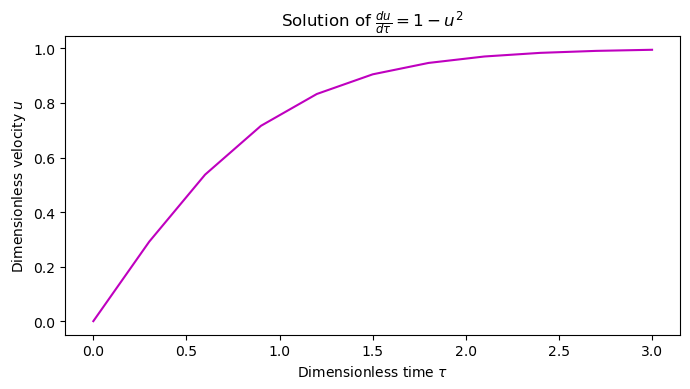

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# Define the ODE: du/dτ = 1 - u^2
def velocity_equation(t, state):
    u = state[0]
    return [1 - u**2]


# Initial condition
u0 = 0.0
initial_state = [u0]

# Time values
t_start = 0.0
t_end = 3.0
num_points = 11

t_eval = np.linspace(t_start, t_end, num_points)


# Solve the ODE
solution = solve_ivp(
    velocity_equation,
    (t_start, t_end),
    initial_state,
    t_eval = t_eval,
    method = "LSODA"
)


# Extract solution
t = solution.t
u = solution.y[0]

print("u =", u)

# Plot solution
plt.figure(figsize = (7, 4))
plt.plot(t, u, "m-")

plt.xlabel(r"Dimensionless time $\tau$")
plt.ylabel(r"Dimensionless velocity $u$")
plt.title(r"Solution of $\frac{du}{d\tau}=1-u^2$")

plt.tight_layout()
plt.show()

## *Example 2 $\hspace{10mm} \displaystyle \frac{du}{d\tau} = -l - \gamma u \hspace{10mm} \frac{dl}{d\tau} = u$*

For this example we are interested in two variables, dimensionless position $l$, and dimensionless velocity $u$, so we have two physical quantities, $y_0$ and $y_1$, respectively. The single 2nd-order differential equation is broken into two 1st-order equations. We'll set $\gamma = 0.1$, experiment with different values of $\gamma$ to see how the results change.

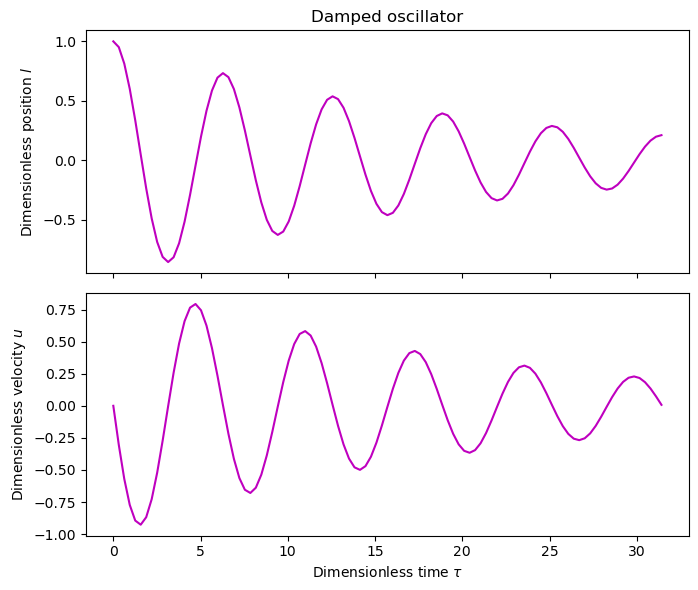

In [6]:
# Damping constant
gamma = 0.1


# Define the system:
# dl/dτ = u
# du/dτ = -l - γu
def damped_oscillator(t, state):
    l = state[0]  # position
    u = state[1]  # velocity

    dldt = u
    dudt = -l - gamma * u

    return [dldt, dudt]


# Initial conditions
l0 = 1.0
u0 = 0.0
initial_state = [l0, u0]


# Time values
t_start = 0.0
t_end = 10.0 * np.pi
num_points = 101

t_eval = np.linspace(t_start, t_end, num_points)


# Solve the system
solution = solve_ivp(
    damped_oscillator,
    (t_start, t_end),
    initial_state,
    t_eval = t_eval,
    method = "LSODA"
)


# Extract solution
t = solution.t
l = solution.y[0]
u = solution.y[1]


# Plot position and velocity
fig, axes = plt.subplots(2, 1, figsize = (7, 6), sharex = True)

axes[0].plot(t, l, "m-")
axes[0].set_ylabel(r"Dimensionless position $l$")
axes[0].set_title("Damped oscillator")

axes[1].plot(t, u, "m-")
axes[1].set_xlabel(r"Dimensionless time $\tau$")
axes[1].set_ylabel(r"Dimensionless velocity $u$")

plt.tight_layout()
plt.show()